In [1]:
import sys; sys.path.append("..")
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from src.data import load_adult
from src.explain import load_tuned_params, fit_xgb, explain_shap, global_importance

os.makedirs("../results", exist_ok=True)
os.makedirs("../figures", exist_ok=True)
X_train, X_test, y_train, y_test = load_adult()
params = load_tuned_params()

In [2]:
pipe = fit_xgb(X_train, y_train, params)
X_s = X_train.sample(2000, random_state=42)
out = explain_shap(pipe, X_s)
grouped = out["grouped"]

margin = pipe[-1].predict(out["Z"], output_margin=True)
err = np.abs(out["base_value"] + out["values"].sum(axis=1) - margin).max()
print(f"additivity error: {err:.2e}")
assert err < 1e-2

additivity error: 4.29e-06


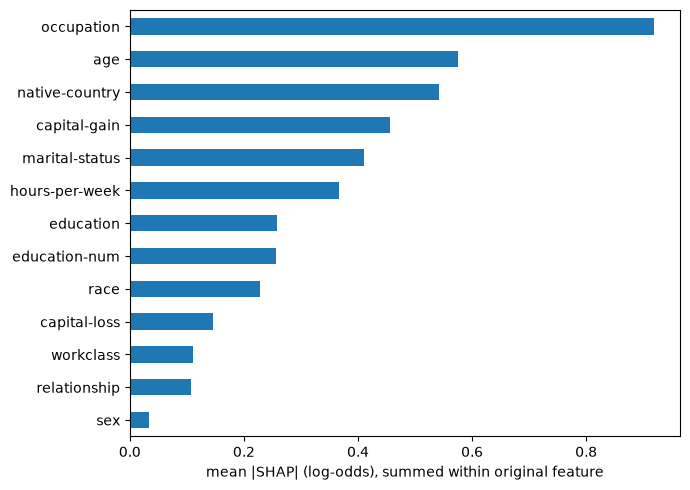

occupation        0.919
age               0.575
native-country    0.542
capital-gain      0.455
marital-status    0.411
hours-per-week    0.366
education         0.258
education-num     0.257
race              0.228
capital-loss      0.146
workclass         0.111
relationship      0.106
sex               0.033
dtype: float32

In [3]:
imp = global_importance(grouped)
imp.to_csv("../results/shap_global_importance.csv", header=["mean_abs_shap"])

fig, ax = plt.subplots(figsize=(7, 5))
imp.sort_values().plot.barh(ax=ax)
ax.set_xlabel("mean |SHAP| (log-odds), summed within original feature")
fig.tight_layout()
fig.savefig("../figures/shap_global_bar.png", dpi=150)
plt.show()
imp.round(3)

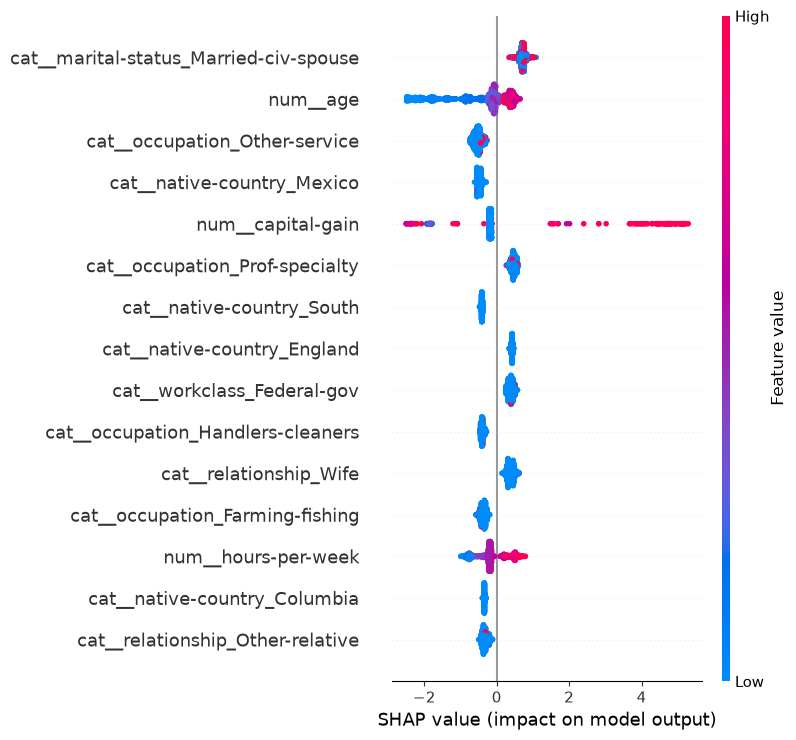

In [4]:
shap.summary_plot(out["values"], out["Z"], feature_names=out["names"],
                  max_display=15, show=False)
plt.gcf().savefig("../figures/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()

row index: 28766 | P(>50K) = 0.5 | true label: 0


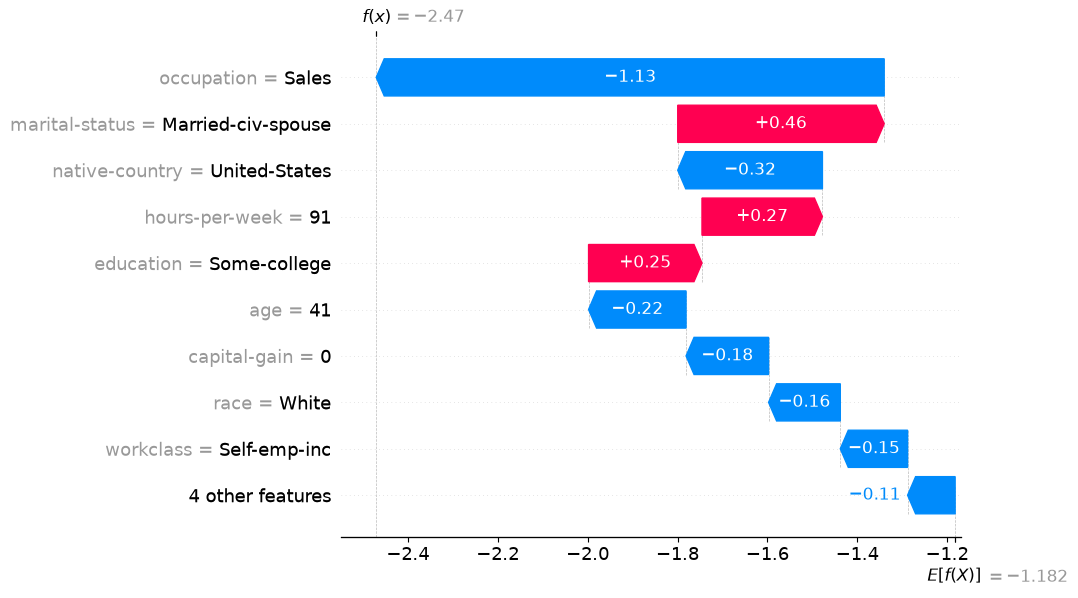

In [5]:
proba = pipe.predict_proba(X_s)[:, 1]
pos = int(np.argmin(np.abs(proba - 0.5)))
idx = X_s.index[pos]
print("row index:", idx, "| P(>50K) =", round(float(proba[pos]), 3),
      "| true label:", int(y_train.loc[idx]))

cols = list(X_s.columns)
labels = [f"{c} = {X_s.loc[idx, c]}" for c in cols]
expl = shap.Explanation(values=grouped.loc[idx, cols].values,
                        base_values=out["base_value"],
                        feature_names=labels)
shap.plots.waterfall(expl, max_display=10, show=False)
plt.gcf().savefig("../figures/shap_waterfall.png", dpi=150, bbox_inches="tight")
plt.show()

with open("../results/explained_instance.json", "w") as f:
    json.dump({"train_row_index": int(idx), "proba": float(proba[pos])}, f)

In [6]:
names = np.array(out["names"])
vals = pd.DataFrame(out["values"], columns=names, index=X_s.index)
Zdf = pd.DataFrame(out["Z"], columns=names, index=X_s.index)

def split_contrib(feature):
    cols = [n for n in names if n.startswith(f"cat__{feature}_")]
    active = (vals[cols] * Zdf[cols]).sum(axis=1)
    inactive = (vals[cols] * (1 - Zdf[cols])).sum(axis=1)
    return {"feature": feature, "levels": len(cols),
            "active |SHAP|": active.abs().mean(),
            "inactive |SHAP|": inactive.abs().mean()}

rows = [split_contrib(f) for f in ["native-country", "occupation", "marital-status", "race", "sex"]]
print(pd.DataFrame(rows).round(3).to_string(index=False))
print(X_s["native-country"].value_counts(normalize=True).head(3).round(3))
print("instance file exists:", os.path.exists("../results/explained_instance.json"))

       feature  levels  active |SHAP|  inactive |SHAP|
native-country      42          0.052            0.564
    occupation      15          0.222            0.902
marital-status       7          0.427            0.445
          race       5          0.038            0.234
           sex       2          0.043            0.057
native-country
United-States    0.889
Mexico           0.020
Missing          0.020
Name: proportion, dtype: float64
instance file exists: True


In [7]:
from scipy.special import expit

print("index unique:", X_s.index.is_unique, "| grouped aligned:", grouped.index.equals(X_s.index))
m = float(pipe[-1].predict(out["Z"][pos:pos+1], output_margin=True)[0])
print("pos, idx:", pos, idx)
print("predict_proba on that row:    ", round(float(pipe.predict_proba(X_s.loc[[idx]])[0, 1]), 4))
print("proba[pos] from Cell 5:       ", round(float(proba[pos]), 4))
print("sigmoid(model margin):        ", round(float(expit(m)), 4), "| margin:", round(m, 3))
print("base + grouped.loc[idx].sum():", round(out["base_value"] + float(grouped.loc[idx].sum()), 3))
print("base + raw values[pos].sum(): ", round(out["base_value"] + float(out["values"][pos].sum()), 3))

index unique: True | grouped aligned: True
pos, idx: 520 28766
predict_proba on that row:     0.4998
proba[pos] from Cell 5:        0.4998
sigmoid(model margin):         0.078 | margin: -2.47
base + grouped.loc[idx].sum(): -2.47
base + raw values[pos].sum():  -2.47


In [8]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split

Xa, Xv, ya, yv = train_test_split(X_train, y_train, test_size=0.25,
                                  stratify=y_train, random_state=0)
pipe_a = fit_xgb(Xa, ya, params)
pi = permutation_importance(pipe_a, Xv, yv, scoring="roc_auc",
                            n_repeats=10, random_state=0, n_jobs=1)
perm = pd.DataFrame({"AUC drop": pi.importances_mean, "std": pi.importances_std},
                    index=Xv.columns).sort_values("AUC drop", ascending=False)
perm.to_csv("../results/permutation_importance.csv")
perm.round(4)

,AUC drop,std
marital-status,0.0681,0.0015
capital-gain,0.0577,0.0022
age,0.0333,0.0018
education-num,0.0184,0.0010
occupation,0.0160,0.0011
capital-loss,0.0144,0.0009
hours-per-week,0.0118,0.0011
relationship,0.0049,0.0005
workclass,0.0033,0.0003
sex,0.0022,0.0004
